# 03 · Uncollected waste vs. litter: where plastic pollution comes from

**Figure 4 of the article.** Plastic can escape the waste system at different points. Cottom et al. (2024) separate five of them:

* **Uncollected waste**: there is no waste collection, so people have to dump or burn their waste themselves
* **Litter**: waste dropped in the street, even though collection exists
* **Disposal**: plastic blown or washed away from dumpsites, or burned there
* **Collection system**: lost from overflowing bins and open trucks
* **Sorting rejects**: unwanted pieces thrown out while sorting for recycling (mostly by informal waste pickers)

The question: **does the main source differ between rich and poor countries?**

Data: `data/processed/cottom2024_income_sources.csv` (made in notebook 00).

In [1]:
# Running this in Google Colab? This cell downloads the project first. (On your own computer it does nothing.)
import os, subprocess, sys
GITHUB_REPO = "MauKruisheer/substack"
ARTICLE = "weeks/20260930-where-does-plastic-end-up"
if "google.colab" in sys.modules:
    if not os.path.exists("/content/repo"):
        subprocess.run(["git", "clone", "-q", "--depth", "1", f"https://github.com/{GITHUB_REPO}", "/content/repo"], check=True)
    os.chdir(f"/content/repo/{ARTICLE}/notebooks")

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.style import COLORS, apply_style, add_title, add_footer, save_figure

apply_style()
df = pd.read_csv(ROOT / "data" / "processed" / "cottom2024_income_sources.csv")
df.head()

,income_code,income_group,source,form,tonnes,kg_per_cap,population_2020
0,World,World,Uncollected waste,debris,18689000.0,2.385500,7834330915
1,World,World,Uncollected waste,open burned,16900000.0,2.157200,7834330915
2,World,World,Litter,debris,1791400.0,0.228660,7834330915
3,World,World,Collection system,debris,917150.0,0.117070,7834330915
4,World,World,Disposal,debris,252250.0,0.032198,7834330915


## Step 1: add up debris and open burning per source

For this figure we don't split debris from open burning; we only ask *where* the plastic escapes.

In [3]:
GROUP_ORDER = ["High income", "Upper-middle income", "Lower-middle income", "Low income"]
SOURCE_ORDER = ["Uncollected waste", "Litter", "Disposal", "Collection system", "Sorting rejects"]

by_source = (df[df["income_group"] != "World"]
             .pivot_table(index="income_group", columns="source", values="tonnes", aggfunc="sum")
             .loc[GROUP_ORDER, SOURCE_ORDER])

share = by_source.div(by_source.sum(axis=1), axis=0) * 100
totals = pd.DataFrame({
    "total_Mt": by_source.sum(axis=1) / 1e6,
    "kg_per_person": df[df["income_group"] != "World"].groupby("income_group")["kg_per_cap"].sum(),
}).loc[GROUP_ORDER]

display(share.round(1))
display(totals.round(2))

source,Uncollected waste,Litter,Disposal,Collection system,Sorting rejects
income_group,,,,,
High income,20.7,48.7,0.0,30.6,0.1
Upper-middle income,68.8,3.2,24.6,2.4,1.1
Lower-middle income,65.5,2.9,28.0,1.4,2.1
Low income,79.7,5.2,10.8,1.1,3.0


,total_Mt,kg_per_person
income_group,,
High income,0.16,0.13
Upper-middle income,14.05,5.19
Lower-middle income,30.41,9.57
Low income,7.49,10.24


Look at the numbers before the chart:

* In **high-income** countries, almost half of the (very small) pollution is **litter**. Waste collection works, so what escapes is mostly what people drop.
* In **low- and middle-income** countries, **uncollected waste** dominates (66–80%). This isn't a choice people make: no one comes to pick up their waste.
* The totals differ enormously: about **0.13 kg per person per year** in high-income countries against **~10 kg** in low-income countries.

Because the totals differ by a factor of ~75, we plot *shares* (each bar = 100%) and write the totals next to the bars.

## Step 2: the chart

saved figures/fig4_pollution_sources_by_income.png (+ .svg)


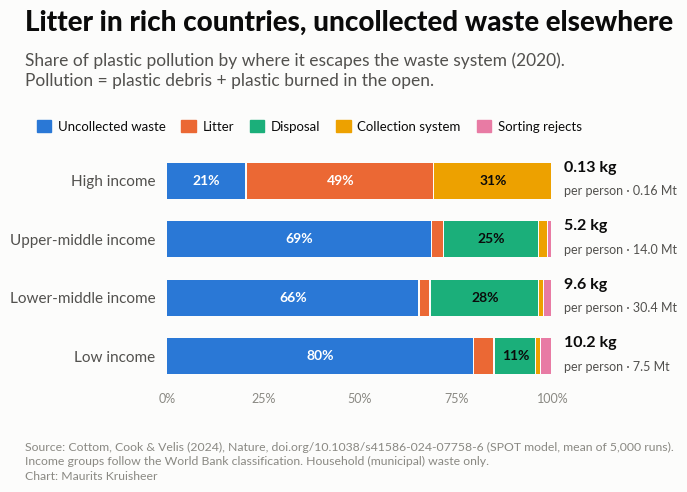

In [4]:
SOURCE_COLORS = {
    "Uncollected waste": COLORS["uncollected"],
    "Litter": COLORS["litter"],
    "Disposal": COLORS["disposal"],
    "Collection system": COLORS["collection"],
    "Sorting rejects": COLORS["rejects"],
}
LIGHT_FILLS = {"Disposal", "Collection system", "Sorting rejects"}  # use dark text on these

fig = plt.figure(figsize=(7.28, 5.1))
ax = fig.add_axes([0.235, 0.215, 0.53, 0.47])

y_positions = range(len(GROUP_ORDER))[::-1]
GAP = 0.35  # small white gap between segments (in % units)

for y, group in zip(y_positions, GROUP_ORDER):
    left = 0
    for source in SOURCE_ORDER:
        width = share.loc[group, source]
        ax.barh(y, max(width - GAP, 0), left=left, height=0.62,
                color=SOURCE_COLORS[source], linewidth=0)
        if width >= 7:
            ax.text(left + width / 2, y, f"{width:.0f}%", ha="center", va="center",
                    fontsize=10, fontweight="bold",
                    color=COLORS["ink"] if source in LIGHT_FILLS else "white")
        left += width
    # totals to the right of each bar
    t = totals.loc[group]
    ax.text(103, y + 0.1, f"{t.kg_per_person:.2f} kg" if t.kg_per_person < 1 else f"{t.kg_per_person:.1f} kg",
            ha="left", va="bottom", fontsize=11.5, fontweight="bold")
    ax.text(103, y - 0.08, f"per person · {t.total_Mt:.2f} Mt" if t.total_Mt < 1 else f"per person · {t.total_Mt:.1f} Mt",
            ha="left", va="top", fontsize=9, color=COLORS["ink_2"])

ax.set_yticks(list(y_positions))
ax.set_yticklabels(GROUP_ORDER, fontsize=11)
ax.tick_params(axis="y", length=0, pad=8)
ax.set_xlim(0, 100)
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xticklabels(["0%", "25%", "50%", "75%", "100%"], fontsize=9)
ax.tick_params(axis="x", length=0, colors=COLORS["ink_3"])
ax.spines[["left", "bottom"]].set_visible(False)
ax.set_ylim(-0.55, len(GROUP_ORDER) - 0.45)

# legend in one row above the bars, in the same order as the segments
handles = [plt.Rectangle((0, 0), 1, 1, color=SOURCE_COLORS[s]) for s in SOURCE_ORDER]
fig.legend(handles, SOURCE_ORDER, loc="upper left", bbox_to_anchor=(0.04, 0.765), ncol=5,
           fontsize=9.5, handlelength=1.1, handleheight=1.1, columnspacing=1.2, handletextpad=0.5)

add_title(fig, "Litter in rich countries, uncollected waste elsewhere",
          "Share of plastic pollution by where it escapes the waste system (2020).\n"
          "Pollution = plastic debris + plastic burned in the open.")
add_footer(fig, "Cottom, Cook & Velis (2024), Nature, doi.org/10.1038/s41586-024-07758-6 (SPOT model, mean of 5,000 runs).",
           "Income groups follow the World Bank classification. Household (municipal) waste only.")
png = save_figure(fig, "fig4_pollution_sources_by_income")
plt.show()

## Step 3: export the data for an interactive (Datawrapper) version

Datawrapper can make the same chart interactive. Upload this CSV and choose *Stacked bars* (100%).

In [5]:
DW = ROOT / "datawrapper"
DW.mkdir(exist_ok=True)
export = share.round(1).reset_index().rename(columns={"income_group": "Income group"})
export["kg per person per year"] = totals["kg_per_person"].round(2).values
export["Total (Mt per year)"] = totals["total_Mt"].round(2).values
export.to_csv(DW / "fig4_pollution_sources_by_income.csv", index=False)
export

source,Income group,Uncollected waste,Litter,Disposal,Collection system,Sorting rejects,kg per person per year,Total (Mt per year)
0,High income,20.7,48.7,0.0,30.6,0.1,0.13,0.16
1,Upper-middle income,68.8,3.2,24.6,2.4,1.1,5.19,14.05
2,Lower-middle income,65.5,2.9,28.0,1.4,2.1,9.57,30.41
3,Low income,79.7,5.2,10.8,1.1,3.0,10.24,7.49


## Try it yourself

* Use `kg_per_cap` instead of shares: how does the chart change, and why is it harder to read?
* Split each source into *debris* and *open burned* (the `form` column). In which income group is open burning the largest part?
* The file also has a `World` row. What share of all plastic pollution worldwide comes from uncollected waste?